Q1 Analysis


,Model,Correct,Incorrect,Total,Accuracy (%)
0,Gemini,31,19,50,62.0
1,Perplexity,32,18,50,64.0
2,Copilot,33,17,50,66.0
3,Kimi,36,14,50,72.0


Q1 Per-Label Analysis


,Model,Answer Label,Correct,Total,Accuracy (%)
0,Gemini,REAL,22,29,75.86
1,Gemini,FAKE,9,21,42.86
2,Perplexity,REAL,21,29,72.41
3,Perplexity,FAKE,11,21,52.38
4,Copilot,REAL,26,29,89.66
5,Copilot,FAKE,7,21,33.33
6,Kimi,REAL,22,29,75.86
7,Kimi,FAKE,14,21,66.67


C:\Users\user\AppData\Local\Temp\ipykernel_27384\1871560935.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x="Model", y="Accuracy (%)", palette="Blues")


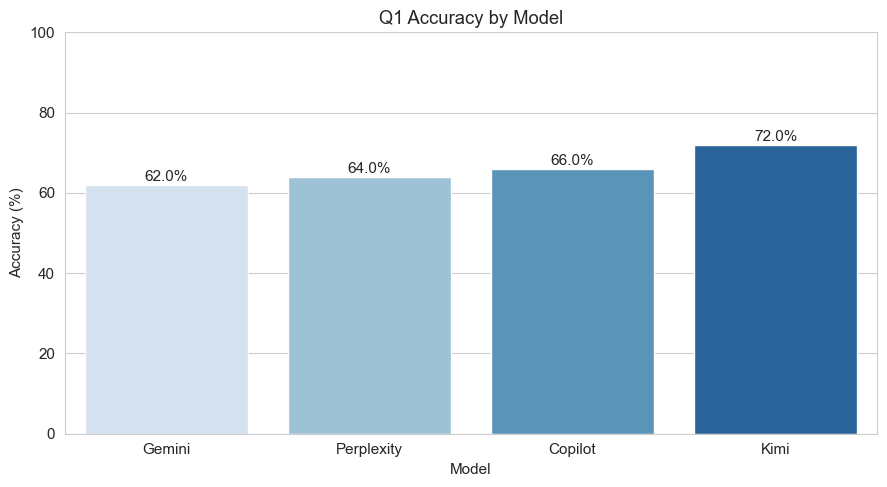

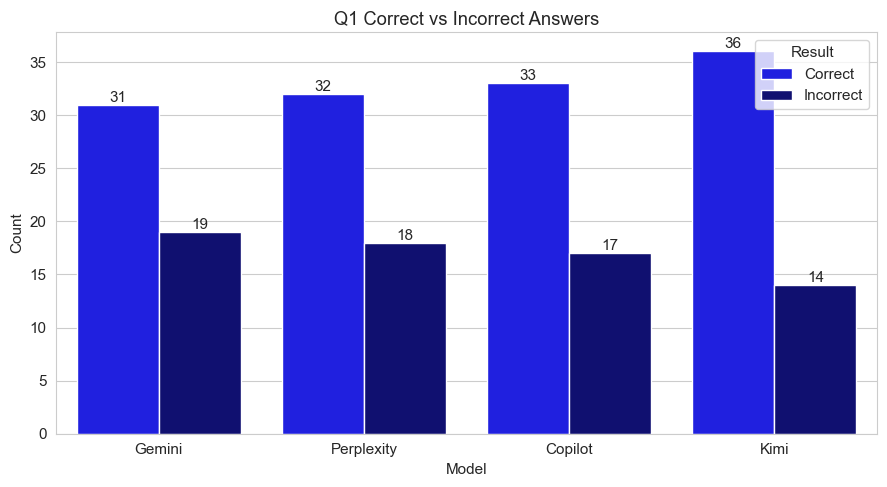

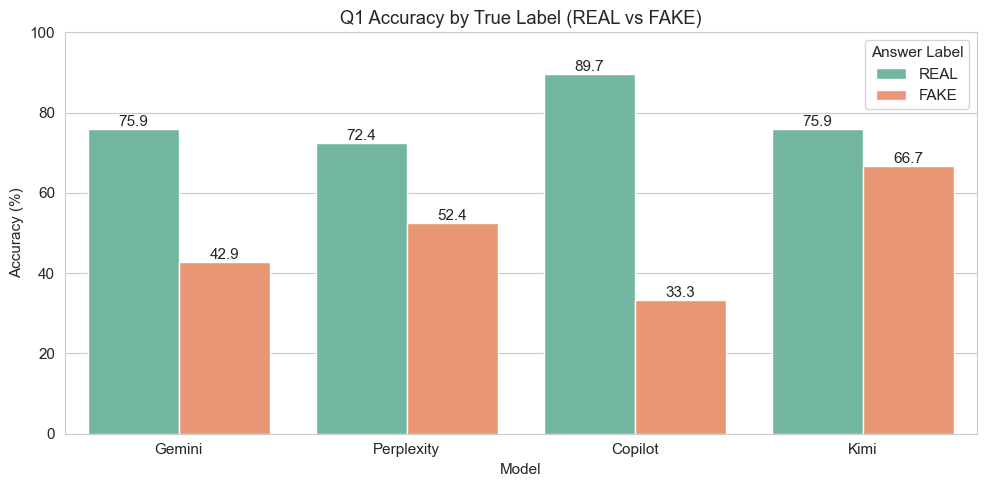

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Load Q1 file
# -----------------------------
df = pd.read_excel("C:/Users/user/Downloads/q1.xlsx")

# Rename columns to safe names
df.columns = ["news", "question_1", "answer", "gemini", "perplexity", "copilot", "kimi"]

# Clean text
for col in df.columns:
    df[col] = df[col].astype(str).str.strip().str.upper()

# Map ground truth
truth_map = {"REAL": "TRUE", "FAKE": "FALSE"}
df["expected"] = df["answer"].map(truth_map)

# -----------------------------
# 2. Model analysis
# -----------------------------
models = ["gemini", "perplexity", "copilot", "kimi"]
results = []

for model in models:
    correct_mask = df[model] == df["expected"]
    correct = int(correct_mask.sum())
    incorrect = int((~correct_mask).sum())
    accuracy = round((correct / len(df)) * 100, 2)

    results.append({
        "Model": model.capitalize(),
        "Correct": correct,
        "Incorrect": incorrect,
        "Total": len(df),
        "Accuracy (%)": accuracy
    })

results_df = pd.DataFrame(results)

print("Q1 Analysis")
display(results_df)

# -----------------------------
# 3. Per-label analysis
# -----------------------------
label_results = []

for model in models:
    for label in ["REAL", "FAKE"]:
        subset = df[df["answer"] == label]
        correct_mask = subset[model] == subset["expected"]
        correct = int(correct_mask.sum())
        total = len(subset)
        accuracy = round((correct / total) * 100, 2) if total > 0 else 0

        label_results.append({
            "Model": model.capitalize(),
            "Answer Label": label,
            "Correct": correct,
            "Total": total,
            "Accuracy (%)": accuracy
        })

label_df = pd.DataFrame(label_results)

print("Q1 Per-Label Analysis")
display(label_df)

# -----------------------------
# 4. Save results
# -----------------------------
results_df.to_csv("q1_model_analysis.csv", index=False)
label_df.to_csv("q1_label_analysis.csv", index=False)

# -----------------------------
# 5. Graphs
# -----------------------------
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

# Accuracy graph
plt.figure()
ax = sns.barplot(data=results_df, x="Model", y="Accuracy (%)", palette="Blues")
plt.title("Q1 Accuracy by Model")
plt.ylim(0, 100)
for i, v in enumerate(results_df["Accuracy (%)"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

# Correct vs Incorrect
melt_df = results_df.melt(
    id_vars="Model",
    value_vars=["Correct", "Incorrect"],
    var_name="Result",
    value_name="Count"
)

plt.figure()
ax = sns.barplot(data=melt_df, x="Model", y="Count", hue="Result", palette=["blue", "navy"])
plt.title("Q1 Correct vs Incorrect Answers")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

# Accuracy by REAL / FAKE
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=label_df, x="Model", y="Accuracy (%)", hue="Answer Label", palette="Set2")
plt.title("Q1 Accuracy by True Label (REAL vs FAKE)")
plt.ylim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")
plt.tight_layout()
plt.show()

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Q1 Analysis


,Model,Correct,Incorrect,Total,Accuracy (%)
0,Gemini,31,19,50,62.0
1,Perplexity,32,18,50,64.0
2,Copilot,33,17,50,66.0
3,Kimi,36,14,50,72.0


Q1 Per-Label Analysis


,Model,Answer Label,Correct,Total,Accuracy (%)
0,Gemini,REAL,22,29,75.86
1,Gemini,FAKE,9,21,42.86
2,Perplexity,REAL,21,29,72.41
3,Perplexity,FAKE,11,21,52.38
4,Copilot,REAL,26,29,89.66
5,Copilot,FAKE,7,21,33.33
6,Kimi,REAL,22,29,75.86
7,Kimi,FAKE,14,21,66.67


C:\Users\user\AppData\Local\Temp\ipykernel_27384\1392864747.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x="Model", y="Accuracy (%)", palette=model_colors)


OSError: [Errno 28] No space left on device

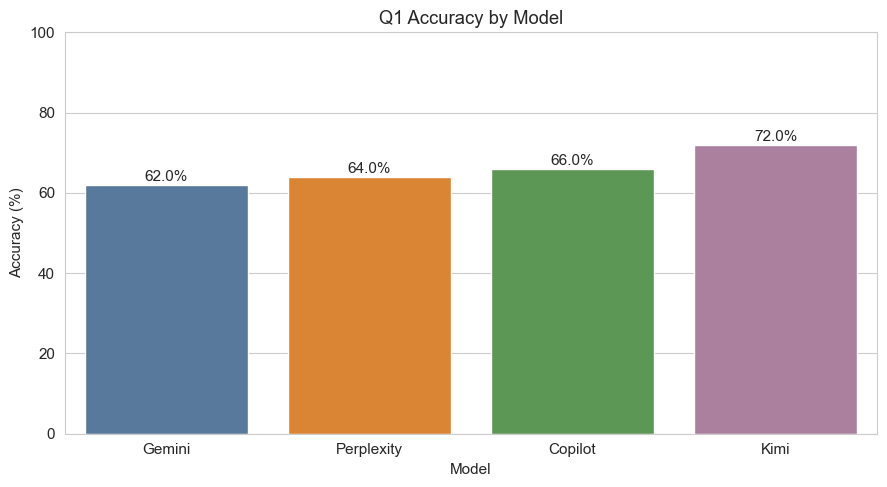

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 0. Save folder
# -----------------------------
save_dir = r"C:/Users/user/Downloads/q1_graphs"
os.makedirs(save_dir, exist_ok=True)

def save_and_show(file_name):
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, file_name), dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------
# 1. Load Q1 file
# -----------------------------
df = pd.read_excel("C:/Users/user/Downloads/q1.xlsx")

# Rename columns to safe names
df.columns = ["news", "question_1", "answer", "gemini", "perplexity", "copilot", "kimi"]

# Clean text
for col in df.columns:
    df[col] = df[col].astype(str).str.strip().str.upper()

# Map ground truth
truth_map = {"REAL": "TRUE", "FAKE": "FALSE"}
df["expected"] = df["answer"].map(truth_map)

# -----------------------------
# 2. Model analysis
# -----------------------------
models = ["gemini", "perplexity", "copilot", "kimi"]
results = []

for model in models:
    correct_mask = df[model] == df["expected"]
    correct = int(correct_mask.sum())
    incorrect = int((~correct_mask).sum())
    accuracy = round((correct / len(df)) * 100, 2)

    results.append({
        "Model": model.capitalize(),
        "Correct": correct,
        "Incorrect": incorrect,
        "Total": len(df),
        "Accuracy (%)": accuracy
    })

results_df = pd.DataFrame(results)

print("Q1 Analysis")
display(results_df)

# -----------------------------
# 3. Per-label analysis
# -----------------------------
label_results = []

for model in models:
    for label in ["REAL", "FAKE"]:
        subset = df[df["answer"] == label]
        correct_mask = subset[model] == subset["expected"]
        correct = int(correct_mask.sum())
        total = len(subset)
        accuracy = round((correct / total) * 100, 2) if total > 0 else 0

        label_results.append({
            "Model": model.capitalize(),
            "Answer Label": label,
            "Correct": correct,
            "Total": total,
            "Accuracy (%)": accuracy
        })

label_df = pd.DataFrame(label_results)

print("Q1 Per-Label Analysis")
display(label_df)

# -----------------------------
# 4. Save results
# -----------------------------
results_df.to_csv("q1_model_analysis.csv", index=False)
label_df.to_csv("q1_label_analysis.csv", index=False)

# -----------------------------
# 5. Graph style
# -----------------------------
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

model_colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"]
correct_incorrect_colors = {"Correct": "#2E8B57", "Incorrect": "#D62728"}
real_fake_colors = {"REAL": "#1F77B4", "FAKE": "#FF7F0E"}

# -----------------------------
# 6. Accuracy graph
# -----------------------------
plt.figure()
ax = sns.barplot(data=results_df, x="Model", y="Accuracy (%)", palette=model_colors)
plt.title("Q1 Accuracy by Model")
plt.ylim(0, 100)

for i, v in enumerate(results_df["Accuracy (%)"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")

save_and_show("q1_accuracy_by_model.png")

# -----------------------------
# 7. Correct vs Incorrect
# -----------------------------
melt_df = results_df.melt(
    id_vars="Model",
    value_vars=["Correct", "Incorrect"],
    var_name="Result",
    value_name="Count"
)

plt.figure()
ax = sns.barplot(
    data=melt_df,
    x="Model",
    y="Count",
    hue="Result",
    palette=correct_incorrect_colors
)
plt.title("Q1 Correct vs Incorrect Answers")

for container in ax.containers:
    ax.bar_label(container)

save_and_show("q1_correct_vs_incorrect.png")

# -----------------------------
# 8. Accuracy by REAL / FAKE
# -----------------------------
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=label_df,
    x="Model",
    y="Accuracy (%)",
    hue="Answer Label",
    palette=real_fake_colors
)
plt.title("Q1 Accuracy by True Label (REAL vs FAKE)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

save_and_show("q1_accuracy_by_label.png")

print(f"Graphs saved in: {save_dir}")